## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Is there a statistically significant difference in the unit price of clothing items associated with women compared to men — whether measured through product gender labels or buyer gender — and does this pattern hold across two independent retail datasets with different data structures and price measurement approaches?

## Background and Prior Work

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

# Hypothesis


We hypothesize that female-associated clothing commands a statistically significantly higher unit price than male-associated clothing. This prediction is supported by prior evidence from the NYC DCA report, which found women's clothing to be approximately 8% more expensive than men's on average. We expect this pattern to manifest both in the price tiers female buyers select and in the labeled prices of women's versus men's apparel products.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [ ]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path
ROOT = Path.cwd()

file1_path = ROOT / "data" / "01-interim" / "cleaned_data.csv"
file2_path = ROOT / "data" / "01-interim" / "retail_sales_dataset_clothing_sales.csv"

df1 = pd.read_csv(file1_path)
df2 = pd.read_csv(file2_path)

df1.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Product_Gender,Clothing_Type
0,2170,17850.0,M,Chicago,12.0,16682.0,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Not Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
1,2171,17850.0,M,Chicago,12.0,16697.0,2019-01-01,GGOEGAAJ073414,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
2,2172,17850.0,M,Chicago,12.0,16704.0,2019-01-01,GGOEGAPB058615,Google Women's Yoga Jacket Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Women,Outerwear
3,2173,17850.0,M,Chicago,12.0,16706.0,2019-01-01,GGOEGAAB010517,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
4,2174,17850.0,M,Chicago,12.0,16715.0,2019-01-01,GGOEYAFB073115,YouTube Men's Fleece Hoodie Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,Outerwear


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [17]:
filtered_df1 = df1[df1['Clothing_Type'] == 'T-Shirts & Shirts']
filtered_df1.head()

,Unnamed: 0,CustomerID,Gender,Location,Tenure_Months,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,...,Coupon_Status,GST,Date,Offline_Spend,Online_Spend,Month,Coupon_Code,Discount_pct,Product_Gender,Clothing_Type
0,2170,17850.0,M,Chicago,12.0,16682.0,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Not Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
1,2171,17850.0,M,Chicago,12.0,16697.0,2019-01-01,GGOEGAAJ073414,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
3,2173,17850.0,M,Chicago,12.0,16706.0,2019-01-01,GGOEGAAB010517,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
5,2175,17850.0,M,Chicago,12.0,16716.0,2019-01-01,GGOEGAAJ073415,Google Men's Short Sleeve Hero Tee Heather,Apparel,...,Clicked,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts
6,2176,13047.0,M,California,43.0,16682.0,2019-01-01,GGOEYAAB031816,YouTube Men's Short Sleeve Hero Tee Black,Apparel,...,Used,0.18,1/1/2019,4500.0,2424.5,1,SALE10,10.0,Men,T-Shirts & Shirts


Before running complex tests, we need to look at the basic descriptive statistics (mean, median, standard deviation) for the prices of men's and women's shirts.

In [18]:
# Group the filtered data by 'Product_Gender' and calculate summary statistics for 'Avg_Price'
price_summary = filtered_df1.groupby('Product_Gender')['Avg_Price'].describe()

print("\nSummary Statistics for T-Shirts & Shirts Prices by Gender:")
print(price_summary)


Summary Statistics for T-Shirts & Shirts Prices by Gender:
                 count       mean       std  min    25%    50%    75%    max
Product_Gender                                                              
Men             6595.0  13.415375  5.948501  3.4  10.63  13.59  16.99  92.84
Women           3230.0  10.307972  6.211785  3.4   4.80   9.60  15.19  62.99


Besed on the output of this code, the mean price for Men's T-Shirts is approximately $13.42, while the mean price for Women's is $10.31. This initial look contradicts the "pink tax" hypothesis, showing that men's shirts are actually priced higher on average in this specific dataset.

To understand the baseline of our data, we will look at the proportion of Men's vs. Women's clothing in the entire dataset. If the dataset is heavily skewed toward one gender, comparing overall averages without grouping by item type could be misleading.

Overall Percentage of Products by Gender:
Product_Gender
Men      66.69%
Women    33.31%
Name: proportion, dtype: str


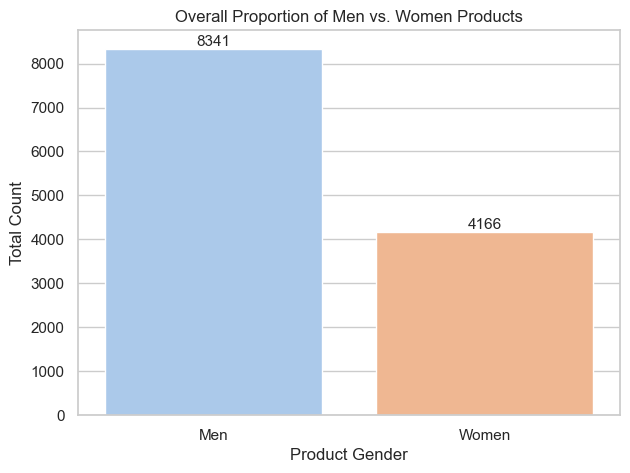

In [21]:
# Calculate the exact percentages
gender_counts = df1['Product_Gender'].value_counts(normalize=True) * 100
print("Overall Percentage of Products by Gender:")
print(gender_counts.round(2).astype(str) + '%')

# Visualize the distribution
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df1, x='Product_Gender', hue='Product_Gender', palette='pastel', legend=False)

plt.title('Overall Proportion of Men vs. Women Products')
plt.xlabel('Product Gender')
plt.ylabel('Total Count')

# Add exact counts on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11)

plt.show()

The bar chart reveals a significant class imbalance in our dataset: Men's products make up roughly 66.7% (8,341 items) of the inventory, while Women's products make up about 33.3% (4,166 items), which is exactly a 2:1 ratio. Given that this dataset appears to contain tech-branded merchandise (e.g., Google, YouTube apparel), this imbalance might reflect the historical demographic skew in the tech industry or the target audience of the retailer. 

While the sample sizes are unequal, we do not need to perform random undersampling. Both groups have a sufficiently large sample size ($n > 4000$) to provide immense statistical power. Furthermore, the tests we selected for our hypothesis (Welch's T-Test and Mann-Whitney U) are specifically robust against unequal sample sizes and differing variances. We can proceed confidently, but we will keep this inventory skew in mind as a characteristic of the dataset.

Visualizing the data helps us understand the spread and shape of the price distributions, which numbers alone might not fully convey.

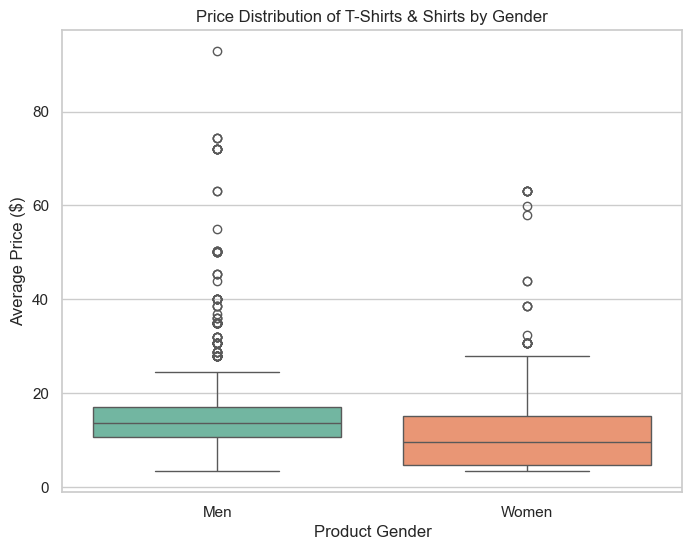

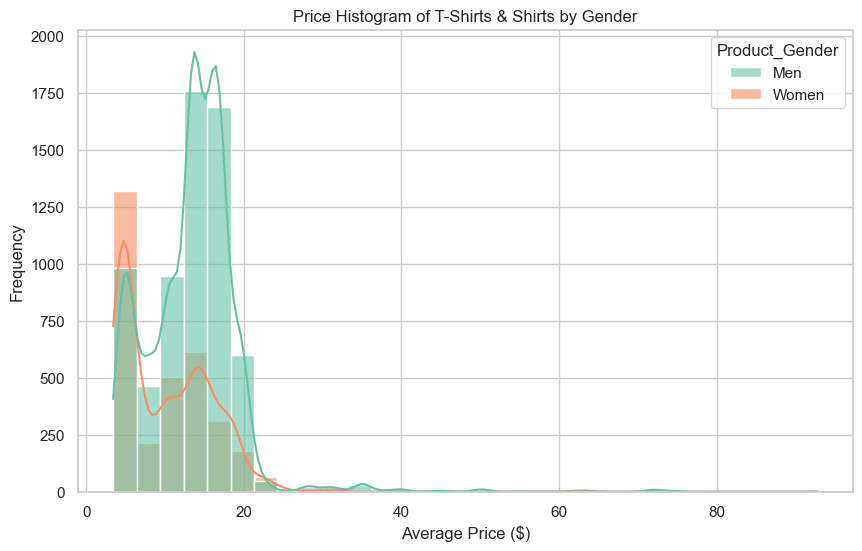

In [19]:
# Set the visual style for seaborn
sns.set_theme(style="whitegrid")

# Create a Boxplot to visualize medians and outliers
plt.figure(figsize=(8, 6))
sns.boxplot(x='Product_Gender', y='Avg_Price', data=filtered_df1, hue='Product_Gender', palette="Set2", legend=False)
plt.title('Price Distribution of T-Shirts & Shirts by Gender')
plt.xlabel('Product Gender')
plt.ylabel('Average Price ($)')
plt.show()

# Create a Histogram to visualize the distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(data=filtered_df1, x='Avg_Price', hue='Product_Gender', kde=True, bins=30, palette="Set2", alpha=0.6)
plt.title('Price Histogram of T-Shirts & Shirts by Gender')
plt.xlabel('Average Price ($)')
plt.ylabel('Frequency')
plt.show()

For the Boxplot: visually confirms that the median (the line inside the box) for men's shirts is higher than for women's. It also shows that men have a wider interquartile range

For the Histogram: it shows that women's shirt prices are heavily right-skewed, meaning most of the shirts are clustered at the lower price points (around $5-$10). Men's prices are more spread out, with a noticeable bump in the $15 range.

To rigorously approach our reseach question and hypothesis, we must run statistical tests. We test the hypothesis that women's prices are significantly greater than men's prices. Since price data is often skewed, we use both a parametric test (Welch's T-Test) and a non-parametric test (Mann-Whitney U Test).

In [20]:
# Separate the prices into two distinct arrays
mens_prices = filtered_df1[filtered_df1['Product_Gender'] == 'Men']['Avg_Price']
womens_prices = filtered_df1[filtered_df1['Product_Gender'] == 'Women']['Avg_Price']

# 1. Welch's T-Test 
# We use equal_var=False because the variances between the two groups might not be the same
# alternative='greater' tests if Women's prices > Men's prices (The Pink Tax hypothesis)
t_stat, p_value_t = stats.ttest_ind(womens_prices, mens_prices, alternative='greater', equal_var=False)

print("\n--- Welch's T-Test ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value_t:.4f}")

# 2. Mann-Whitney U Test
# A non-parametric test that is robust to outliers and non-normal distributions
u_stat, p_value_mw = stats.mannwhitneyu(womens_prices, mens_prices, alternative='greater')

print("\n--- Mann-Whitney U Test ---")
print(f"U-statistic: {u_stat:.4f}")
print(f"P-value: {p_value_mw:.4f}")

# Final Conclusion Logic
alpha = 0.05
if p_value_mw < alpha:
    print("\nConclusion: Reject the null hypothesis. There is statistically significant evidence of a Pink Tax (Women's shirts are more expensive).")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is NO statistically significant evidence of a Pink Tax. In fact, men's shirts may be more expensive.")


--- Welch's T-Test ---
T-statistic: -23.6172
P-value: 1.0000

--- Mann-Whitney U Test ---
U-statistic: 7160399.0000
P-value: 1.0000

Conclusion: Fail to reject the null hypothesis. There is NO statistically significant evidence of a Pink Tax. In fact, men's shirts may be more expensive.


The statistical tests yield a p-value of 1.0. In hypothesis testing (using a standard alpha level of 0.05), a p-value this high means we completely fail to reject the null hypothesis. Statistically speaking, there is zero evidence of a "pink tax" in the T-shirts & Shirts category of this dataset.

### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [ ]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them